We can generate spatial clusters of earthquake data through a DBScan (Density based spatial clustering of applications with noise). This will allow us to group and seemlessly visualize our earthquake data spatially. Note there is a number in parenthesis in the legend, these represent the number of seismic events M >= 4 in each respective cluster/group during our time frame (01/01/90 - 6/30/26).

In [ ]:
import folium
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
import numpy as np

url = "https://earthquake.usgs.gov/fdsnws/event/1/query?format=csv&starttime=1990-01-01&endtime=2026-06-30&minlatitude=32.5&minlongitude=-124.5&maxlatitude=42.0&maxlongitude=-114.1&minmagnitude=4.0"
df = pd.read_csv(url)

coords = df[['latitude', 'longitude']].values

kms_per_radian = 6371.0088
epsilon = 50 / kms_per_radian

db = DBSCAN(eps=epsilon, min_samples=5, metric='haversine').fit(np.radians(coords))

df['Cluster_ID'] = db.labels_

map_center = [df['latitude'].mean(), df['longitude'].mean()]
earthquake_map = folium.Map(location=map_center, zoom_start=5)

cluster_colors = {-1: 'gray', 0: 'red', 1: 'blue', 2: 'green', 3: 'purple', 4: 'orange', 5: 'darkred', 6: 'yellow', 7: 'cyan', 8: 'lime', 9: 'fuchsia'}

for _, row in df.iterrows():
    c_id = row['Cluster_ID']
    color_val = cluster_colors.get(c_id, 'black')

    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5,
        color=color_val,
        fill=True,
        fill_color=color_val,
        fill_opacity=0.7,
        popup=f"Cluster: {c_id}<br>Magnitude: {row.get('mag', 'N/A')}"
    ).add_to(earthquake_map)


# filter the rows with Mag >= 6M, style them larger and give them a distinctive color
major_events = df[df['mag'] >= 6.0]

for _, row in major_events.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=10,
        color='brown',
        fill=True,
        fill_color='snow',
        fill_opacity=0.9,
        weight=2,
        popup=f"<b>Major earthquake</b><br>Magnitude: {row['mag']}<br>Cluster: {row['Cluster_ID']}"
    ).add_to(earthquake_map)


cluster_counts = df['Cluster_ID'].value_counts()


legend_html = f"""
<div style="
    position: fixed;
    bottom: 30px; right: 30px; width: 180px; height: auto;
    background-color: white; z-index:9999; font-size:14px;
    padding: 10px; border: 2px solid grey; border-radius: 5px;
    box-shadow: 0 0 15px rgba(0,0,0,0.2);">
    <b>DBSCAN Legend</b><br>
    <i style="background:gray; width:12px; height:12px; float:left; margin-right:8px; border-radius:50%;"></i> Noise (-1) ({cluster_counts.get(-1, 0)})<br>
    <i style="background:red; width:12px; height:12px; float:left; margin-right:8px; border-radius:50%;"></i> Cluster 0 ({cluster_counts.get(0, 0)})<br>
    <i style="background:blue; width:12px; height:12px; float:left; margin-right:8px; border-radius:50%;"></i> Cluster 1 ({cluster_counts.get(1, 0)})<br>
    <i style="background:green; width:12px; height:12px; float:left; margin-right:8px; border-radius:50%;"></i> Cluster 2 ({cluster_counts.get(2, 0)})<br>
    <i style="background:purple; width:12px; height:12px; float:left; margin-right:8px; border-radius:50%;"></i> Cluster 3 ({cluster_counts.get(3, 0)})<br>
    <i style="background:orange; width:12px; height:12px; float:left; margin-right:8px; border-radius:50%;"></i> Cluster 4 ({cluster_counts.get(4, 0)})<br>
    <i style="background:darkred; width:12px; height:12px; float:left; margin-right:8px; border-radius:50%;"></i> Cluster 5 ({cluster_counts.get(5, 0)})<br>
    <i style="background:yellow; width:12px; height:12px; float:left; margin-right:8px; border-radius:50%;"></i> Cluster 6 ({cluster_counts.get(5, 0)})<br>
    <i style="background:cyan; width:12px; height:12px; float:left; margin-right:8px; border-radius:50%;"></i> Cluster 7 ({cluster_counts.get(5, 0)})<br>
    <i style="background:lime; width:12px; height:12px; float:left; margin-right:8px; border-radius:50%;"></i> Cluster 8 ({cluster_counts.get(5, 0)})<br>
    <i style="background:fuchsia; width:12px; height:12px; float:left; margin-right:8px; border-radius:50%;"></i> Cluster 9 ({cluster_counts.get(5, 0)})<br>
    <hr style="margin: 8px 0;">
    <i style="background:snow; width:14px; height:14px; float:left; margin-right:8px; border-radius:50%; border: 1px solid brown;"></i> <b>Mag ≥ 6.0 Event</b><br>
</div>
"""

earthquake_map.get_root().html.add_child(folium.Element(legend_html))

earthquake_map

This cell is used to determine the b-value and a-value. The api will provide adequete data to compute these values using a maximum likelihood estimation at the state level. This cell will print the respective a-value and b-value and graph the magnitude and frequency. These values depict earthquakes within our choosen parameters. We/you can change these parameters via the api, but this study shows quakes >= 4M between Jan 1, 1990 - June 30, 2026 in both California and Nevada.

MLE a-value: 7.05
MLE b-value: 0.96


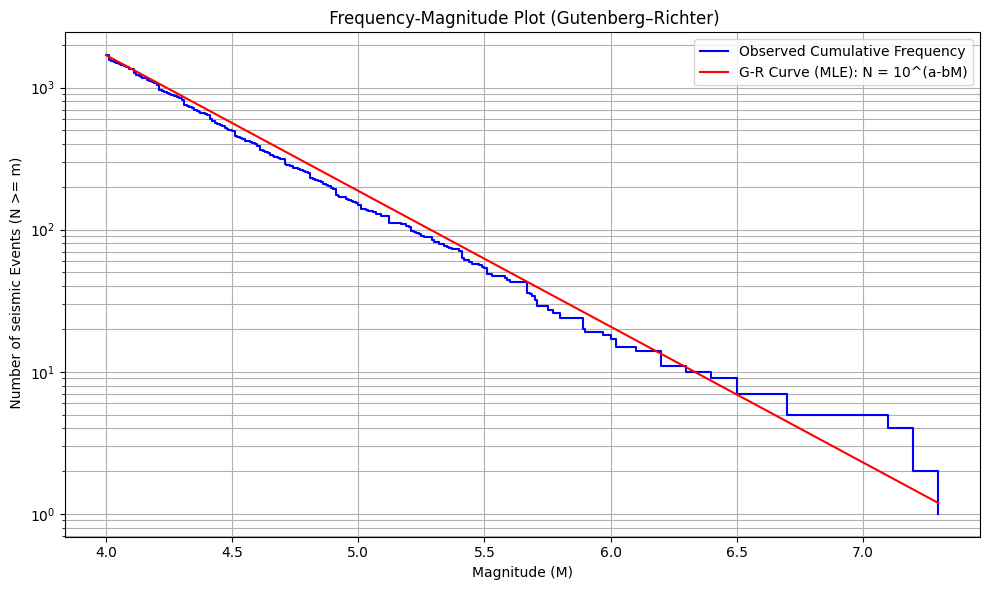

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import urllib.request

#api
url = "https://earthquake.usgs.gov/fdsnws/event/1/query?format=csv&starttime=1990-01-01&endtime=2026-06-30&minlatitude=32.5&minlongitude=-124.5&maxlatitude=42.0&maxlongitude=-114.1&minmagnitude=4.0"
df = pd.read_csv(url)


min_magnitude = 4.0

mags_for_mle = df[df['mag'] >= min_magnitude]['mag'].values

#calc. b-value
mean_mag = np.mean(mags_for_mle)
b_mle = np.log10(np.e) / (mean_mag - (min_magnitude - 0.05))


N_total = len(mags_for_mle)
a_mle = np.log10(N_total) + b_mle * min_magnitude

print(f"MLE a-value: {a_mle:.2f}")
print(f"MLE b-value: {b_mle:.2f}")


bins = np.sort(df['mag'].unique())

gr_table = []

for m in bins:
    N_observed = (df['mag'] >= m).sum()
    if N_observed > 0:
        gr_table.append([m, N_observed, np.log10(N_observed)])

gr_df = pd.DataFrame(gr_table, columns=['magnitude', 'N_observed', 'log10N_observed'])


plt.figure(figsize=(10, 6))

# Plot (Gutenberg-Richter)


plt.step(gr_df['magnitude'], gr_df['N_observed'], where='post', color='blue', label='Observed Cumulative Frequency')


m_vals = np.arange(min_magnitude, gr_df['magnitude'].max() + 0.01, 0.01)
N_pred_mle = 10**(a_mle - b_mle * m_vals)
plt.plot(m_vals, N_pred_mle, color='red', label=f'G-R Curve (MLE): N = 10^(a-bM)')

plt.xlabel('Magnitude (M)')
plt.ylabel(' Number of seismic Events (N >= m)')
plt.yscale('log')
plt.title(' Frequency-Magnitude Plot (Gutenberg–Richter)')
plt.legend()
plt.grid(True, which="both", ls="-")

plt.tight_layout()
plt.show()

Due to the limitations of the maximun likelihood estimation (lack of data within some clusters) we will calculate the b-values for each region/cluster using a linear regression. We will map these values and their respective clusters using our DBScan ( Density-based spatial clustering application with noise).

In [13]:
import numpy as np
from sklearn.linear_model import LinearRegression
from matplotlib import colormaps
import matplotlib.colors as colors
import pandas as pd
import folium
from sklearn.cluster import DBSCAN

# DBScan and api
url = "https://earthquake.usgs.gov/fdsnws/event/1/query?format=csv&starttime=1990-01-01&endtime=2026-06-30&minlatitude=32.5&minlongitude=-124.5&maxlatitude=42.0&maxlongitude=-114.1&minmagnitude=4.0"
df = pd.read_csv(url)

coords = df[['latitude', 'longitude']].values

kms_per_radian = 6371.0088
epsilon = 50 / kms_per_radian

db = DBSCAN(eps=epsilon, min_samples=5, metric='haversine').fit(np.radians(coords))

df['Cluster_ID'] = db.labels_

cluster_results = []

# Regression-based b-value per cluster
for cluster_id in sorted(df['Cluster_ID'].unique()):
    if cluster_id == -1:
        continue

    cluster_df = df[df['Cluster_ID'] == cluster_id]
    mags = np.sort(cluster_df['mag'].values)

    # Counts
    N = np.array([np.sum(mags >= m) for m in mags])
    logN = np.log10(N)

    # Linear regression
    X = mags.reshape(-1, 1)
    y = logN
    model = LinearRegression().fit(X, y)

    a_value = model.intercept_
    b_value = -model.coef_[0]

    cluster_results.append({
        "Cluster_ID": cluster_id,
        "a_value": a_value,
        "b_value": b_value,
        "num_quakes": len(cluster_df)
    })


gr_df = pd.DataFrame(cluster_results)


b_lookup = dict(zip(gr_df['Cluster_ID'], gr_df['b_value']))
a_lookup = dict(zip(gr_df['Cluster_ID'], gr_df['a_value']))


b_vals = list(b_lookup.values())
norm = colors.Normalize(vmin=min(b_vals), vmax=max(b_vals))
cmap = colormaps['seismic']

b_colors = {
    cid: colors.to_hex(cmap(norm(bv)))
    for cid, bv in b_lookup.items()
}

# Map
map_center = [df['latitude'].mean(), df['longitude'].mean()]
bvalue_map = folium.Map(location=map_center, zoom_start=5)

for _, row in df.iterrows():
    cid = row['Cluster_ID']

    if cid == -1:
        color_val = 'gray'
        b_str = "N/A"
    else:
        color_val = b_colors.get(cid, 'black')
        b_val = b_lookup.get(cid)
        b_str = f"{b_val:.3f}"

    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5,
        color=color_val,
        fill=True,
        fill_color=color_val,
        fill_opacity=0.7,
        popup=(
            f"Cluster: {cid}<br>"
            f"Magnitude: {row['mag']}<br>"
            f"b-value: {b_str}"
        )
    ).add_to(bvalue_map)

# Legend
legend_html = """
<div style="
    position: fixed;
    bottom: 30px; left: 30px; width: 260px;
    background-color: white; z-index:9999; font-size:14px;
    padding: 10px; border: 2px solid grey; border-radius: 5px;">
    <b>Gutenberg–Richter Parameters</b><br>
    <i>Cluster a- and b-values</i><br><br>
"""

for cid in b_lookup:
    legend_html += f"""
    <div>
        <span style="background:{b_colors[cid]};
                     width:12px; height:12px;
                     display:inline-block;
                     margin-right:8px;"></span>
        Cluster {cid}: b = {b_lookup[cid]:.2f}, a = {a_lookup[cid]:.2f}
    </div>
    """

legend_html += "</div>"

bvalue_map.get_root().html.add_child(folium.Element(legend_html))

bvalue_map